In [ ]:
import matplotlib.pyplot as plt
import json
import pickle as pkl
import os
import numpy as np
from collections import defaultdict
from scipy.stats import pearsonr


In [26]:
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\CNN_TRAINING_SESSIONS" # Modify this to your data path folder
parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\Download_from_paper" # Modify this to your data path folder
# parent=r"E:\neurospark_mat\CNN_TRAINING_SESSIONS"
# parent=r"E:\neurospark_mat\Download_from_paper"

bandpass=[100,250]
downsampled_fs = 30000 # Downsampled frequency
factor=downsampled_fs//1000
time_max=20
window_size=0.1
sample_ratio=0.25
scaling_factor=1
refractory=0.0003
percentile=False
fraction=(0,1)
downsample_factor=30000//downsampled_fs
overlap=int(time_max/2)

In [ ]:
adaptive_thresholds=False
load_path = os.path.join(os.getcwd())
filename = f"thresholds_and_spikerates_adapt{time_max}.pkl" if adaptive_thresholds else f"thresholds_and_spikerates_fixed{time_max}.pkl"
file_path = os.path.join(load_path, filename)
with open(file_path, "rb") as f:
    data = pkl.load(f)
    thresholds = data["thresholds"]
    spike_rates = data["spike_rates"]

In [28]:
# Example: extract X% of precomputed thresholds
fraction_start =  0.8 
fraction_end = 1.0

extracted_thresholds = {}
extracted_spike_rates = {}
for dataset in thresholds:
    dataset_thresholds = thresholds[dataset]
    dataset_spikerates = spike_rates[dataset]
    extracted_dataset_thresholds = {}
    extracted_dataset_spikerates = {}

    for channel in dataset_thresholds:
        channel_thresholds = dataset_thresholds[channel]
        channel_spikerates = dataset_spikerates[channel]
        total_windows = len(channel_thresholds)

        start_idx = int(fraction_start * total_windows)
        end_idx = int(fraction_end * total_windows)

        extracted_dataset_thresholds[channel] = channel_thresholds[start_idx:end_idx]
        extracted_dataset_spikerates[channel] = channel_spikerates[start_idx:end_idx]

    extracted_spike_rates[dataset] = extracted_dataset_spikerates
    extracted_thresholds[dataset] = extracted_dataset_thresholds


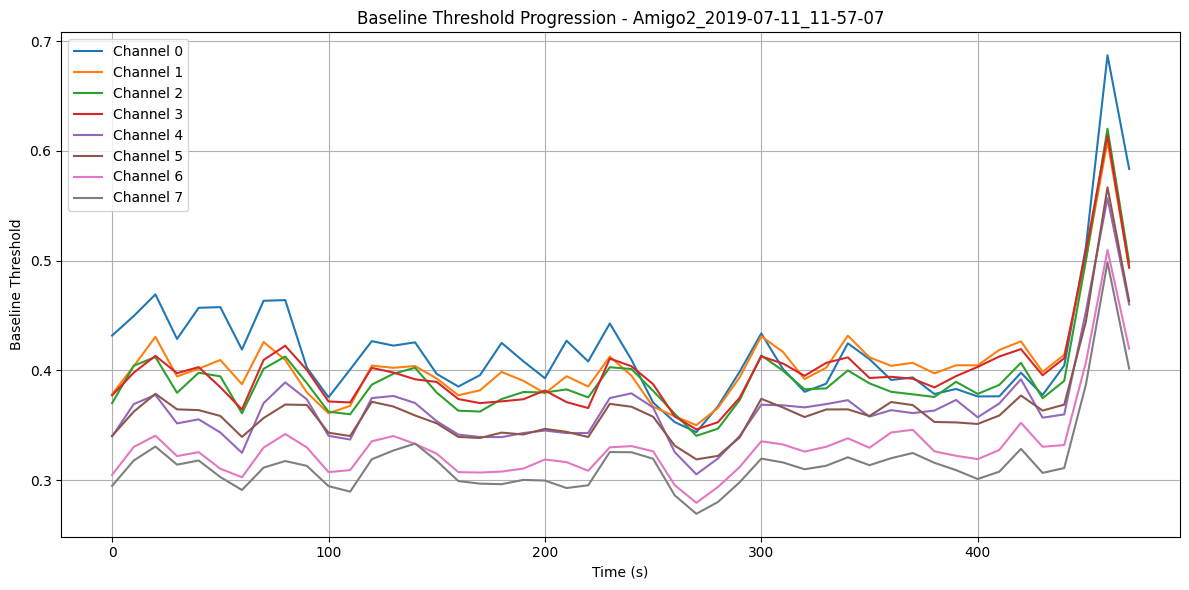

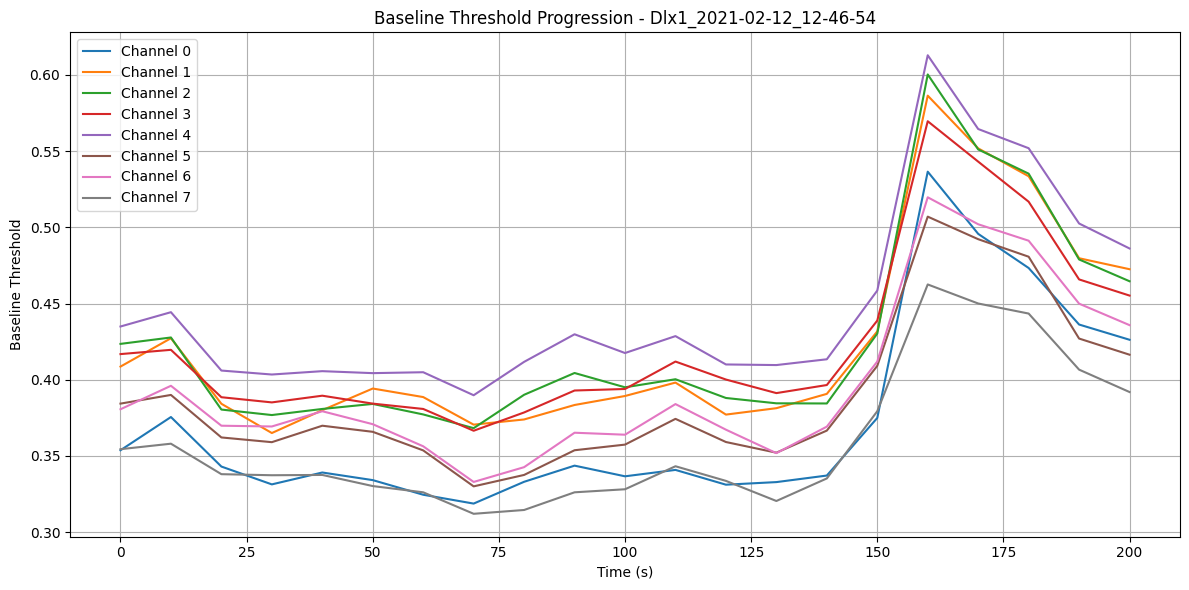

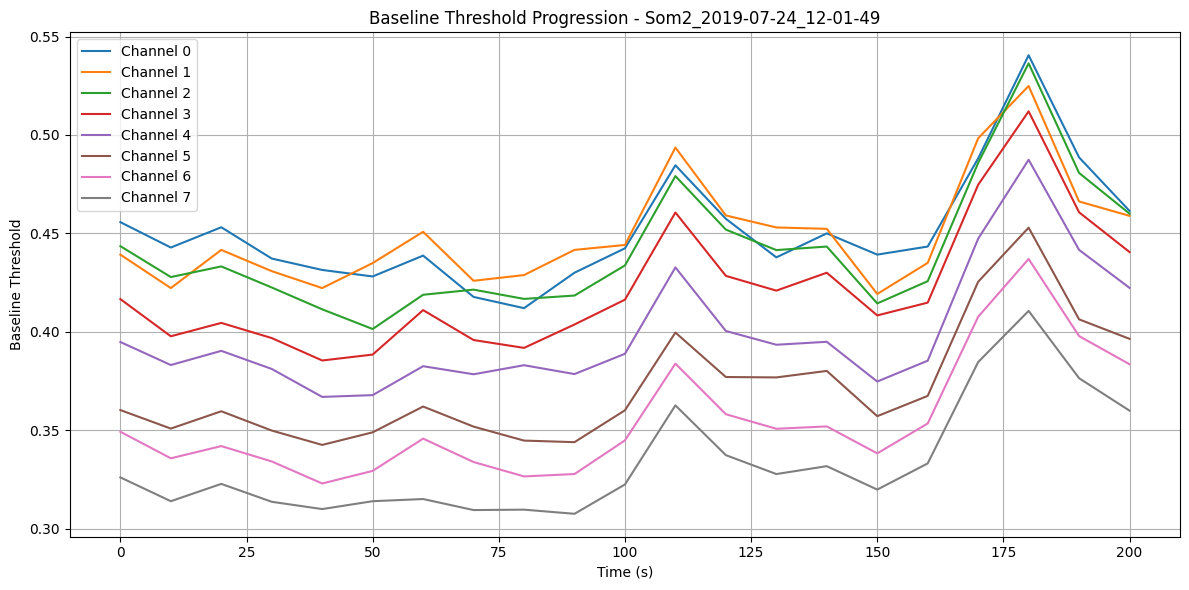

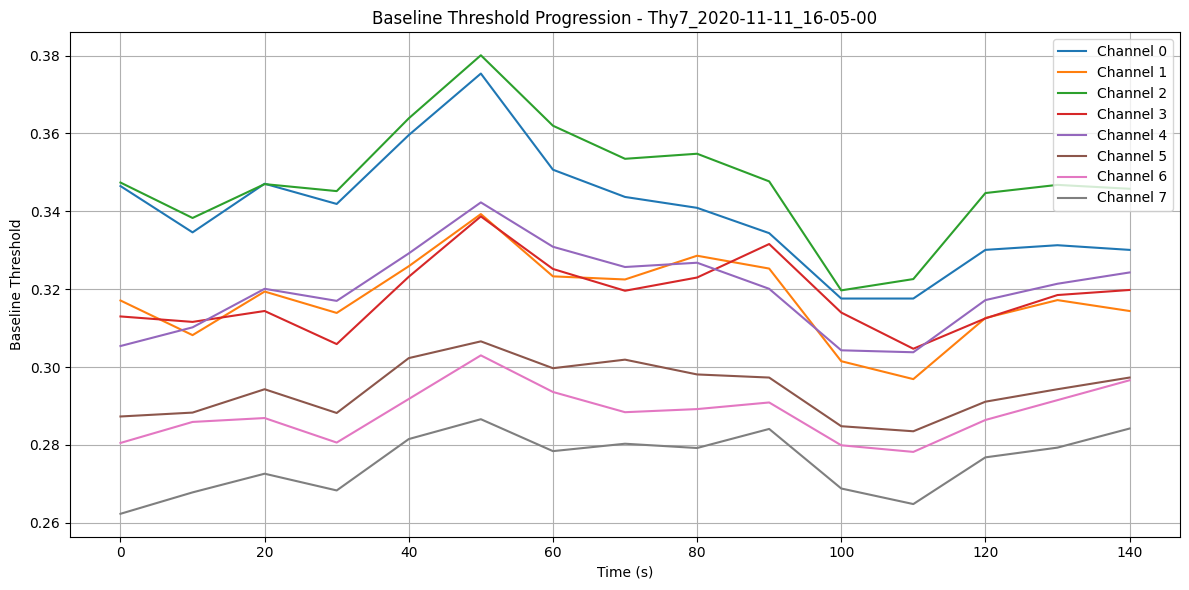

In [ ]:
# Evolution of thresholds with time

# Loop through each dataset
for dataset_name, channel_dict in extracted_thresholds.items():
    
    plt.figure(figsize=(12, 6))
    plt.title(f"Baseline Threshold Progression - {dataset_name}")
    
    # Loop through each channel
    for channel, threshold_list in channel_dict.items():
        time_axis = [i * overlap for i in range(len(threshold_list))]
        plt.plot(time_axis,threshold_list, label=f"Channel {channel}")
        if channel=="0":
            print()
    
    plt.xlabel("Time (s)")
    plt.ylabel("Baseline Threshold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Processing dataset: Amigo2_2019-07-11_11-57-07
Dataset: Amigo2_2019-07-11_11-57-07, Pearson r = 0.425, p = 1.840e-84


C:\Users\NCN\AppData\Local\Temp\ipykernel_25964\600674820.py:33: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(thresholds_dataset, spikerates_dataset, alpha=0.6, s=30,


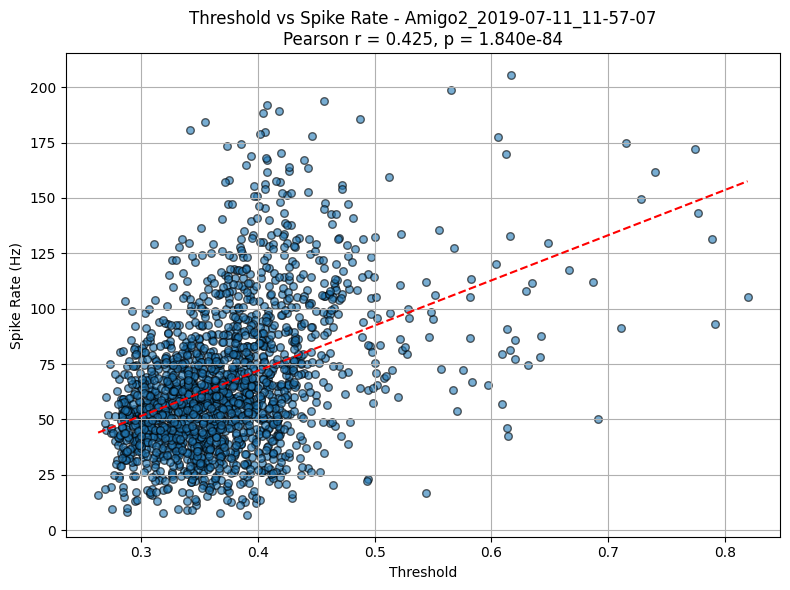

Processing dataset: Dlx1_2021-02-12_12-46-54
Dataset: Dlx1_2021-02-12_12-46-54, Pearson r = 0.351, p = 7.864e-25


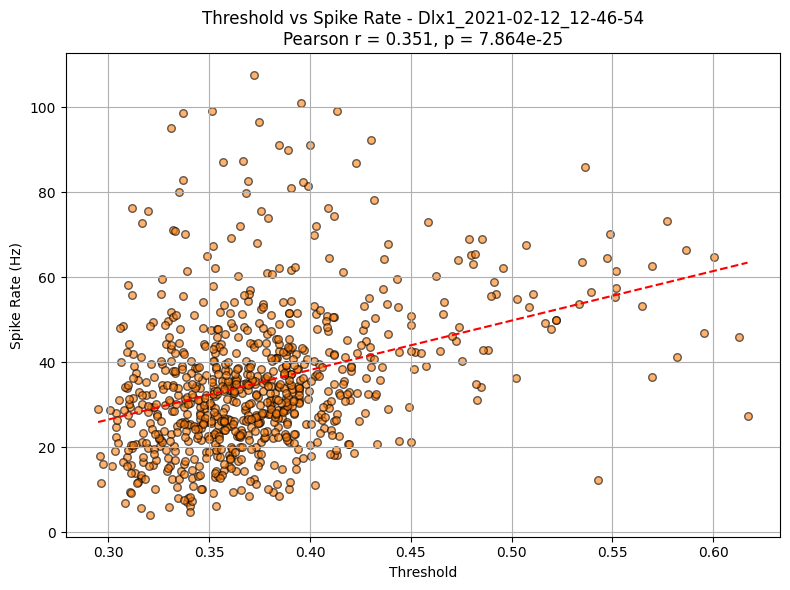

Processing dataset: Som2_2019-07-24_12-01-49
Dataset: Som2_2019-07-24_12-01-49, Pearson r = 0.282, p = 2.175e-16


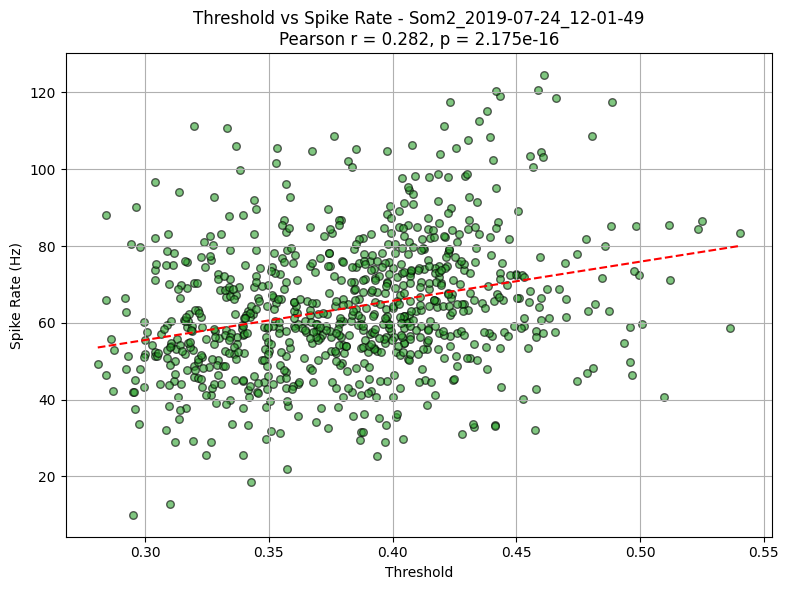

Processing dataset: Thy7_2020-11-11_16-05-00
Dataset: Thy7_2020-11-11_16-05-00, Pearson r = 0.344, p = 1.237e-17


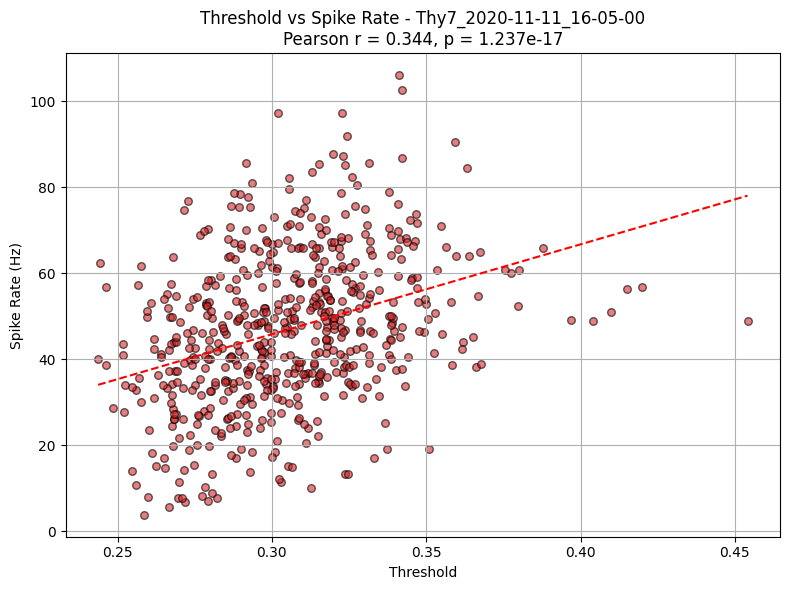

In [30]:
from scipy.stats import pearsonr

colors = plt.cm.tab10.colors  # color palette

# Store for overall plot
threshold_all = []
spike_all = []
dataset_labels = []

for i, dataset_name in enumerate(thresholds.keys()):
    thresholds_dataset = []
    spikerates_dataset = []
    print(f"Processing dataset: {dataset_name}")
    for channel in thresholds[dataset_name].keys():
        channel_rates = spike_rates[dataset_name][channel]
        channel_thresholds = thresholds[dataset_name][channel]
        if len(channel_rates) != len(channel_thresholds):
            print(f"Length mismatch for dataset {dataset_name}, channel {channel}: {len(channel_rates)} vs {len(channel_thresholds)}")
        thresholds_dataset.extend(channel_thresholds)
        spikerates_dataset.extend(channel_rates)

    # Switched axis in correlation
    r_val, p_val = pearsonr(thresholds_dataset, spikerates_dataset)

    threshold_all.extend(thresholds_dataset)
    spike_all.extend(spikerates_dataset)
    dataset_labels.extend([dataset_name] * len(spikerates_dataset))

    print(f"Dataset: {dataset_name}, Pearson r = {r_val:.3f}, p = {p_val:.3e}")
    plt.figure(figsize=(8, 6))

    # Switched axis in plot
    plt.scatter(thresholds_dataset, spikerates_dataset, alpha=0.6, s=30,
                c=colors[i % len(colors)], edgecolors='k')

    # Switched x and y for trendline
    slope, intercept = np.polyfit(thresholds_dataset, spikerates_dataset, 1)
    x_vals = np.array([min(thresholds_dataset), max(thresholds_dataset)])
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color='red', linestyle='--', label='Trendline')

    plt.title(f"Threshold vs Spike Rate - {dataset_name}\nPearson r = {r_val:.3f}, p = {p_val:.3e}")
    plt.xlabel("Threshold")
    plt.ylabel("Spike Rate (Hz)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Overall Pearson r = 0.377, p = 9.34e-139


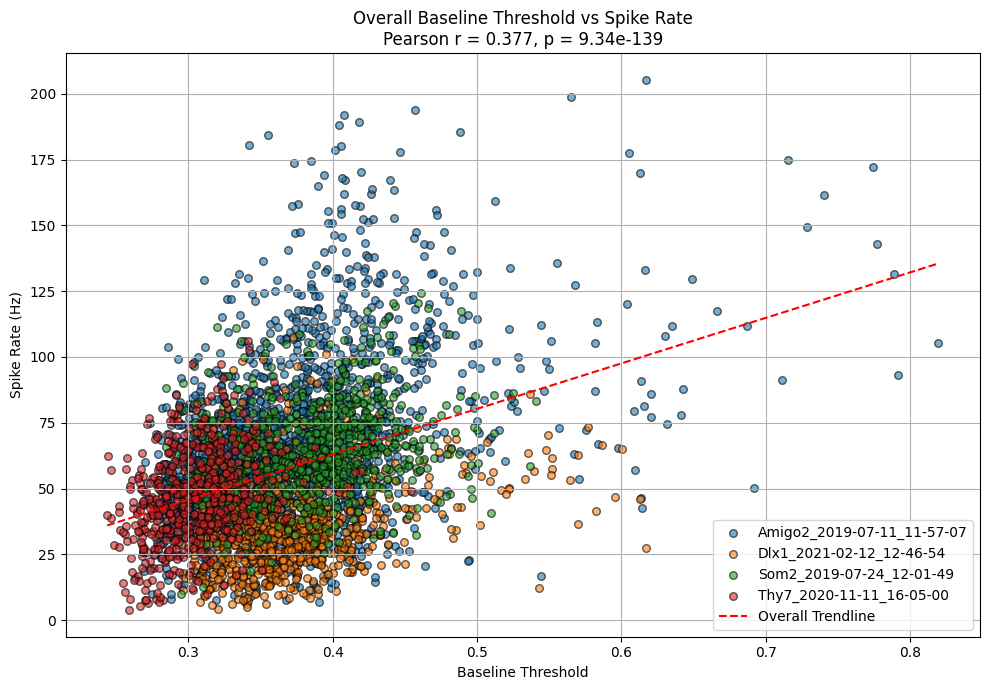

In [31]:
# 2. Combined plot with color-coded datasets
plt.figure(figsize=(10, 7))
unique_datasets = list(thresholds.keys())

for i, dataset_name in enumerate(unique_datasets):
    # Mask for current dataset
    mask = [label == dataset_name for label in dataset_labels]
    plt.scatter(
        [threshold_all[j] for j in range(len(threshold_all)) if mask[j]],  # now x-axis
        [spike_all[j] for j in range(len(spike_all)) if mask[j]],          # now y-axis
        alpha=0.6, s=30, c=[colors[i % len(colors)]], edgecolors='k', label=dataset_name
    )

# Overall correlation (flipped args)
r_all, p_all = pearsonr(threshold_all, spike_all)
print(f"Overall Pearson r = {r_all:.3f}, p = {p_all:.2e}")

# Fit and plot overall trendline (flipped)
slope, intercept = np.polyfit(threshold_all, spike_all, 1)
x_vals = np.array([min(threshold_all), max(threshold_all)])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', linestyle='--', label='Overall Trendline')

plt.title(f"Overall Baseline Threshold vs Spike Rate\nPearson r = {r_all:.3f}, p = {p_all:.2e}")
plt.xlabel("Baseline Threshold")
plt.ylabel("Spike Rate (Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Evaluate Results


In [ ]:
adapt=20
identifier="30000_1000_100"
identifier=f"{identifier}_adaptable{adapt}" if adapt>0 else f"{identifier}"
# identifier="1000_200_median"
dataset_path=os.path.join(os.getcwd(),os.pardir,"train_pedro","dataset_up_down",identifier)
datasets=os.listdir(dataset_path)
if "config.json" in datasets:
    datasets.remove("config.json")

results_path=os.path.join(os.getcwd(),os.pardir,os.pardir,"snnTorch","eval","live_results")
filename=f"all_network_results_{identifier}.pkl"
path_file=os.path.join(results_path, filename)
with open(path_file, "rb") as f:
    all_networks_info = pkl.load(f)

In [ ]:
# # Load results
# with open(results_json, 'r') as f:
#     results = json.load(f)
# # Load spikes
# spikes = np.load(spikes, allow_pickle=True)

In [ ]:
# # Get some parameters
# parameters=results["parameters"]
# ripple_detection_offset=parameters["ripple_detection_offset"]

# refractory_period=parameters["refractory_period_gt"]
refractory_period=0 # in ms

# max_detection_offset=parameters["max_detection_offset"]

# tolerance=parameters["tolerance"]
tolerance=20 # in ms
padding=100 # in ms
max_detection_offset=80 # in ms
jitter=100

In [36]:
# Read the datasets and evaluate the results
information_dataset={}
for dataset_id,dataset in enumerate(datasets):

    data_path= os.path.join(dataset_path, dataset)
    print(f"Processing dataset: {data_path}")
    data=np.load(os.path.join(data_path, "spike_data.npy"))  # Load the input data (UP/DN spikes)
    ripples=np.load(os.path.join(data_path, "ripples.npy"))  # Load the GT data (HFO Insertion Timing)
    dataset_results = results[dataset]  # Get the results for the current dataset

    # ripples_start = ripples[:, 0]  # Get the GT Insertion Timing (first column of the ripples array)
    if SEEDED:
        # If the data is seeded, we need to slice the data to the desired time window
        data = data[window,:]
        ripples_window = []
        for ripple in ripples:
            if ripple[1] >= window[0] and ripple[0] <= window[-1]:
                    ripples_window.append(ripple)
        ripples=np.array(ripples_window)-window[0]-tolerance  # Adjust the GT Insertion Timing to the new window
    else:
        ripples=ripples-tolerance
    
    num_hfo_events = len(ripples)
    dataset_spikes= spikes[dataset_id*8:(dataset_id+1)*8,:]

    ripple_hits = {}  # List of sets: which channels hit each ripple
    undetected_ripples = []  # Indices of ripples missed by all channels
    num_channels = dataset_spikes.shape[0]
    filtered_spikes = []  # List of filtered spikes for each channel
    
    # GET VALID SPIKES by REMOVING REFRACTORY PERIOD VIOLATIONS
    for ch_spikes in dataset_spikes:
        # Sort spikes just in case (important)
        sorted_spikes = np.sort(ch_spikes)
        
        if len(sorted_spikes) == 0:
            filtered_spikes.append(np.array([]))
            continue

        valid = [sorted_spikes[0]]
        for spike in sorted_spikes[1:]:
            if spike - valid[-1] >= refractory_period:
                valid.append(spike)
        filtered_spikes.append(np.array(valid))

    ripples_start = ripples[:, 0]  # Get the GT Insertion Timing (first column of the ripples array)
    # DETECT RIPPLE HITS
    for idx, ripple_time in enumerate(ripples_start):
        detected_channels = set()

        for ch in range(num_channels):
            valid_window_start= ripple_time - tolerance
            valid_window_end = ripple_time + max_detection_offset + tolerance
            ch_spikes = filtered_spikes[ch]
            in_window = np.any((ch_spikes >= valid_window_start) & 
                            (ch_spikes <= valid_window_end))
            if in_window:
                detected_channels.add(ch)

        ripple_hits[idx] = detected_channels  # store in dict by ripple index

        if not detected_channels:
            undetected_ripples.append(idx)

    # COLLECT FALSE POSITIVE SPIKES
    valid_detection_ranges = []

    for ripple_time in ripples:
        start = ripple_time[0] - tolerance
        end = ripple_time[0] + max_detection_offset + tolerance + padding
        # end=max(end,ripple_time[1] + padding)  # Ensure end is at least ripple_time[1] + padding
        valid_detection_ranges.append((start, end))

    # STEP 2: Function to check if a spike is inside any ripple detection window
    def is_tp(spike_time, valid_ranges):
        for start, end in valid_ranges:
            if start <= spike_time <= end:
                return True
        return False
    
    fp_spikes_by_channel = defaultdict(list)
    for ch in range(num_channels):
        # STEP 1: Create set of all valid detection time ranges
        for spike_time in filtered_spikes[ch]:
            if not is_tp(spike_time, valid_detection_ranges):
                fp_spikes_by_channel[ch].append(spike_time)
    
    # Group by time with jitter
    overlap_counts = defaultdict(set)  # spike_time -> set of channels that had an FP there
    fp_timing_to_channels = defaultdict(set)
    jitter= np.round(max_detection_offset) # half of the max detection offset
    for ch, spike_list in fp_spikes_by_channel.items():
        for spike_time in spike_list:
            matched_time = None

            # Try to match this spike to an existing FP group (within jitter)
            for t in range(int(spike_time - jitter),int( spike_time + jitter + 1)):
                if t in fp_timing_to_channels:
                    matched_time = t
                    break
            if matched_time is not None:
                fp_timing_to_channels[matched_time].add(ch)
            else:
                fp_timing_to_channels[spike_time].add(ch)

    information_dataset[dataset] = {
    "ripple_hits": ripple_hits,  # now a dict: ripple_idx -> set of channels
    "undetected_ripples": undetected_ripples,  # list of ints
    "filtered_spikes": filtered_spikes,  # list of arrays
    "fp_spikes_by_channel": fp_spikes_by_channel,  # dict: ch -> [spike times]
    "fp_timing_to_channels": dict(fp_timing_to_channels),  # dict: time -> set(channels)
    }


Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\extract_Nripples\thresholds_and_spikerates\..\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Amigo2_2019-07-11_11-57-07
Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\extract_Nripples\thresholds_and_spikerates\..\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Dlx1_2021-02-12_12-46-54
Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\extract_Nripples\thresholds_and_spikerates\..\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Som2_2019-07-24_12-01-49
Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\extract_Nripples\thresholds_and_spikerates\..\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Thy7_2020-11-11_16-05-00


In [ ]:
threshold_tp_fp_fn_by_window = defaultdict(lambda: defaultdict(dict))  # {dataset: {channel: {window_idx: {...}}}}
window_metrics_by_dataset = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for dataset_name, info in information_dataset.items():
    data_path = os.path.join(dataset_path, dataset_name)
    ripple_hits = info["ripple_hits"]  # dict: ripple_idx -> set of channels
    ripples=np.load(os.path.join(data_path, "ripples.npy"))  # Load the GT data (HFO Insertion Timing)
    data=np.load(os.path.join(data_path, "spike_data.npy"))  # Load the input data (UP/DN spikes)

    filtered_spikes = info["filtered_spikes"]
    
    for ch, ch_spikes in enumerate(filtered_spikes):
        ch_thresholds = extracted_thresholds[dataset_name][str(ch)]
        ch_rates = extracted_spike_rates[dataset_name][str(ch)]

        max_time = int(data.shape[0])
        n_windows = int(np.ceil(max_time /(overlap*1000)))

        for window_idx in range(n_windows):
            start_time = window_idx * overlap*1000
            end_time = start_time + overlap*1000
            spikes_in_window = ch_spikes[(ch_spikes >= start_time) & (ch_spikes < end_time)]

            # Ripples overlapping this window
            ripples_in_window = []
            ripple_ids_in_window=[]
            for i,ripple in enumerate(ripples):
                ripple_start = ripple[0] - tolerance
                ripple_end = ripple[0] + max_detection_offset + tolerance
                if not (ripple_end < start_time or ripple_start > end_time):
                    ripples_in_window.append((ripple_start, ripple_end))
                    ripple_ids_in_window.append(i)

            TP = 0
            FP = 0
            FN = 0
            matched_spikes = set()
            matched_ripples = set()
            for ripple_idx in ripple_ids_in_window:
                if ripple_idx in ripple_hits.keys():
                    if ch in ripple_hits[ripple_idx]:
                        TP += 1
                    else:
                        FN += 1

         
            # Match spikes to ripples with jitter
            for spike_time in spikes_in_window:
                matched = False
                for idx, (r_start, r_end) in enumerate(ripples_in_window):
                    if (r_start) <= spike_time <= (r_end + padding):
                            matched = True
                            matched_spikes.add(spike_time)
                            break
                    
            last_fp_time = -np.inf  # reset per window

            for spike_time in spikes_in_window:
                if spike_time in matched_spikes:
                    continue

                near_ripple = any(spike_time <= r_end + padding for (_, r_end) in ripples_in_window)
                if near_ripple:
                    continue

                if spike_time - last_fp_time > jitter:
                    FP += 1
                    last_fp_time = spike_time


            # Fetch threshold
            if window_idx < len(ch_thresholds):
                threshold = ch_thresholds[window_idx]
                rate= ch_rates[window_idx]
            else:
                threshold = None
                rate=None

            # Store
            threshold_tp_fp_fn_by_window[dataset_name][ch][window_idx] = {
                "TP": TP,
                "FP": FP,
                "FN": FN,
                "threshold": threshold,
                "rate":rate ,
            }
            # Save to plotting dictionary
            window_metrics_by_dataset[dataset_name][ch]["TP"].append(TP)
            window_metrics_by_dataset[dataset_name][ch]["FP"].append(FP)
            window_metrics_by_dataset[dataset_name][ch]["FN"].append(FN)
            window_metrics_by_dataset[dataset_name][ch]["threshold"].append(threshold)
            window_metrics_by_dataset[dataset_name][ch]["rate"].append(rate)
            print(f"Dataset: {dataset_name}, Channel: {ch}, Window: {window_idx}, TP: {TP}, FP: {FP}, FN: {FN}, Threshold: {threshold}, Rate: {rate}")


Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 0, TP: 6, FP: 3, FN: 4, Threshold: 0.4317, Rate: 120.0
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 1, TP: 5, FP: 0, FN: 2, Threshold: 0.4495, Rate: 129.1
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 2, TP: 3, FP: 1, FN: 0, Threshold: 0.4692, Rate: 131.85
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 3, TP: 4, FP: 0, FN: 1, Threshold: 0.4286, Rate: 137.95
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 4, TP: 8, FP: 0, FN: 1, Threshold: 0.457, Rate: 118.3
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 5, TP: 10, FP: 1, FN: 0, Threshold: 0.4576, Rate: 147.60000000000002
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 6, TP: 4, FP: 10, FN: 0, Threshold: 0.4189, Rate: 157.20000000000002
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 7, TP: 2, FP: 0, FN: 0, Threshold: 0.4634, Rate: 138.3
Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 8, TP: 3, FP: 2, F

48


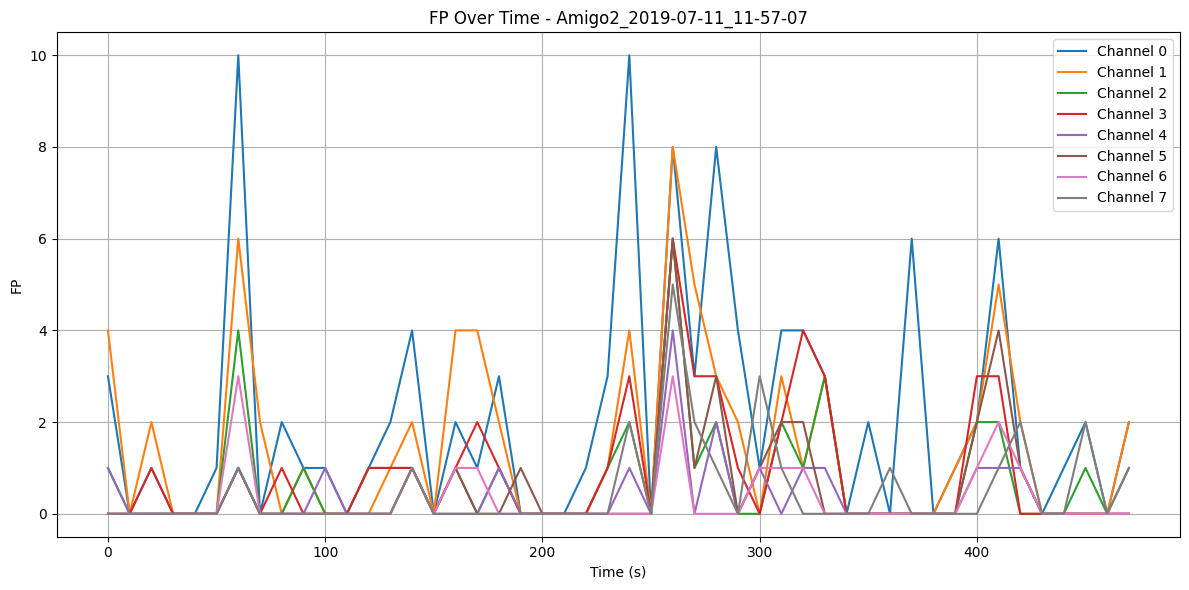

21


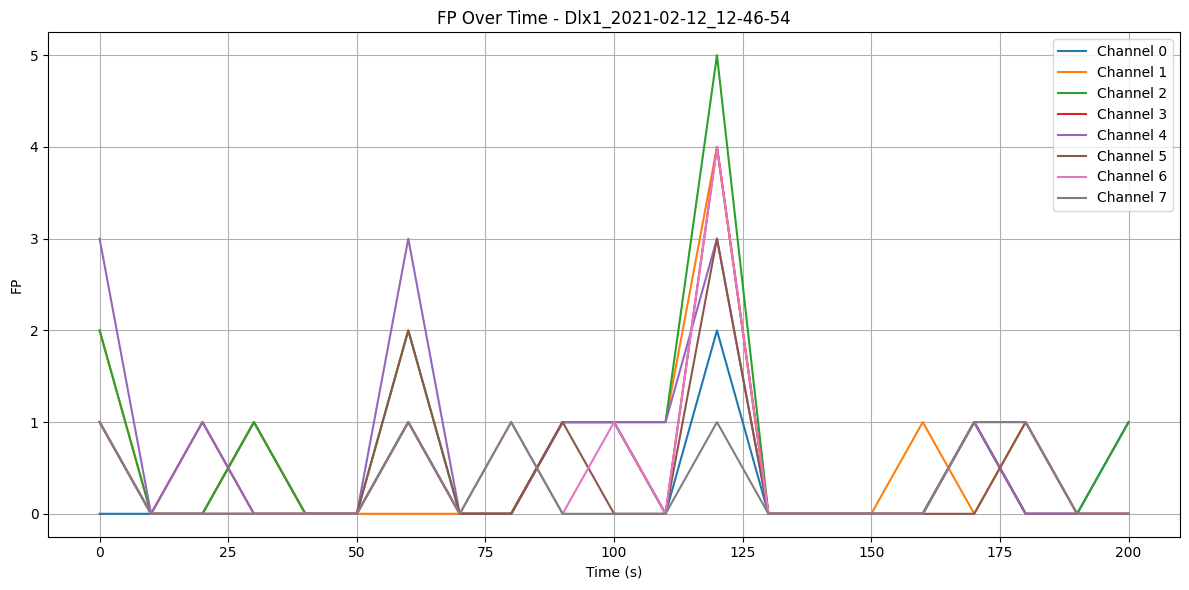

21


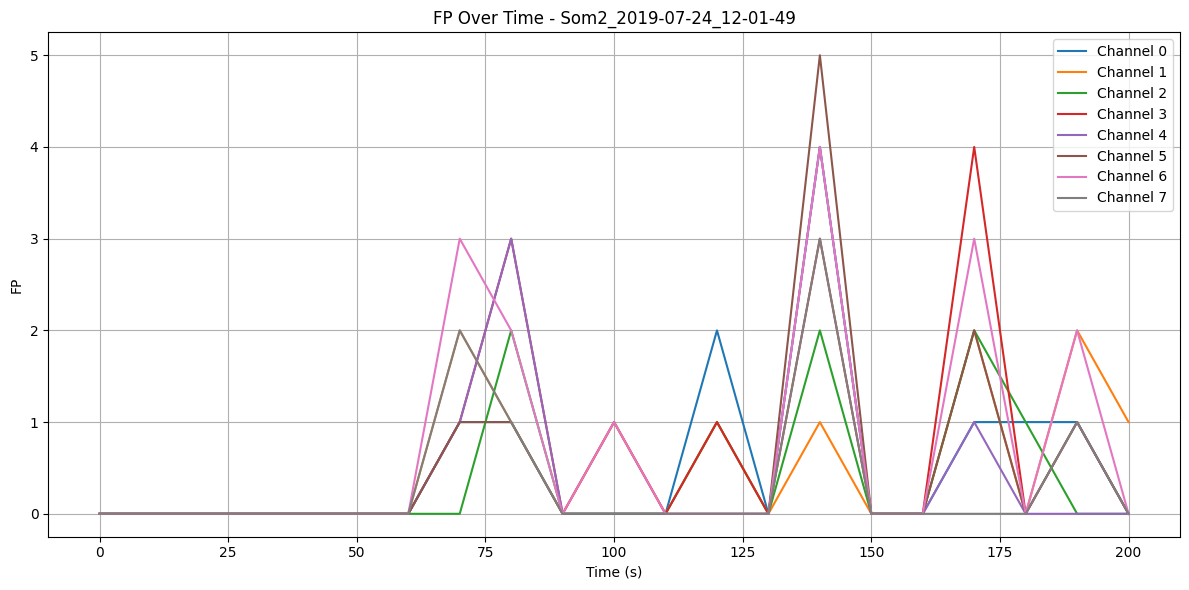

15


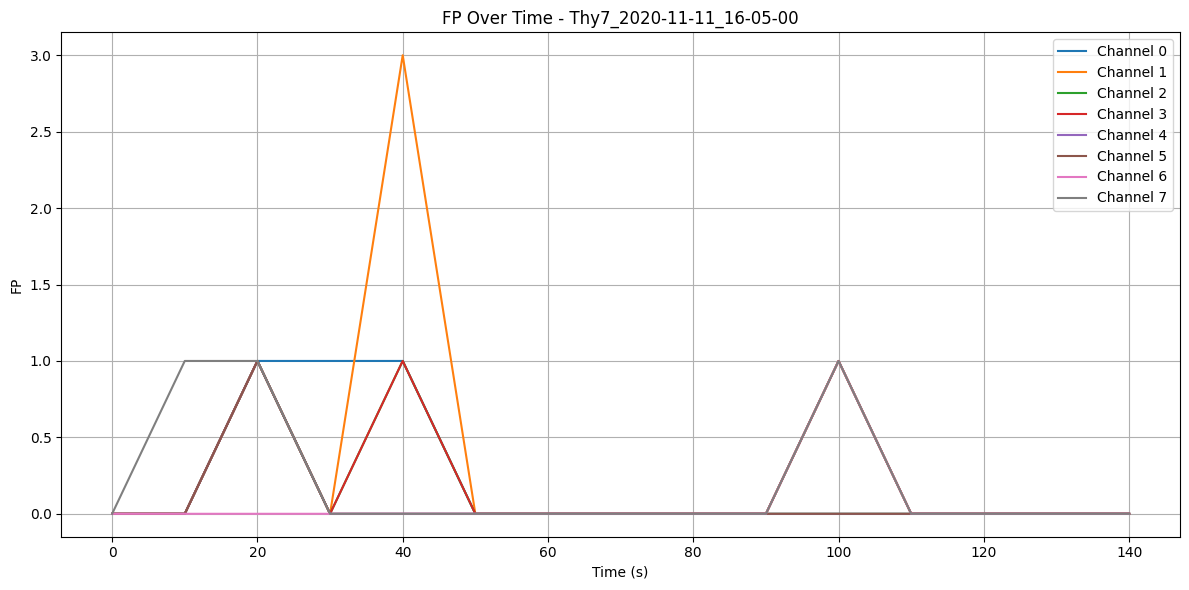

In [38]:
var="FP"
for dataset_name, channels in window_metrics_by_dataset.items():
    plt.figure(figsize=(12, 6))
    plt.title(f"{var} Over Time - {dataset_name}")

    for channel, metrics in channels.items():
        times = np.arange(len(metrics["FP"])) * overlap  # Time in seconds
        plt.plot(times, metrics[f"{var}"], label=f"Channel {channel}")
        

    print(len(channels[0]["TP"]))

    plt.xlabel("Time (s)")
    plt.ylabel(f"{var}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

C:\Users\NCN\AppData\Local\Temp\ipykernel_25964\3517907428.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(thresholds_dataset, metric_dataset, alpha=0.6, s=30,


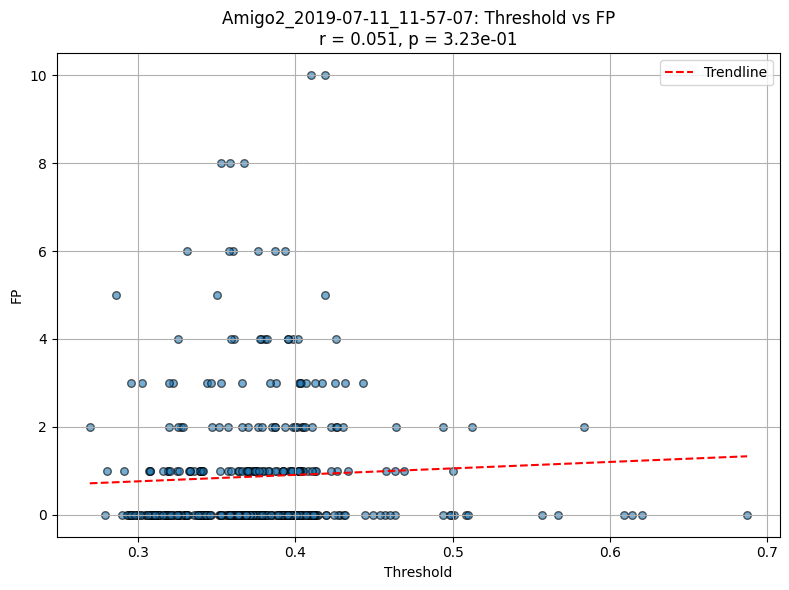

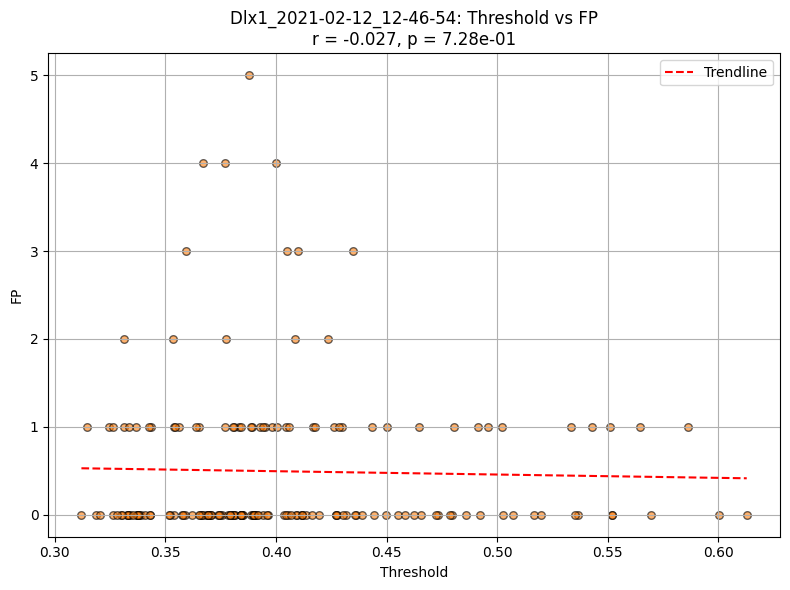

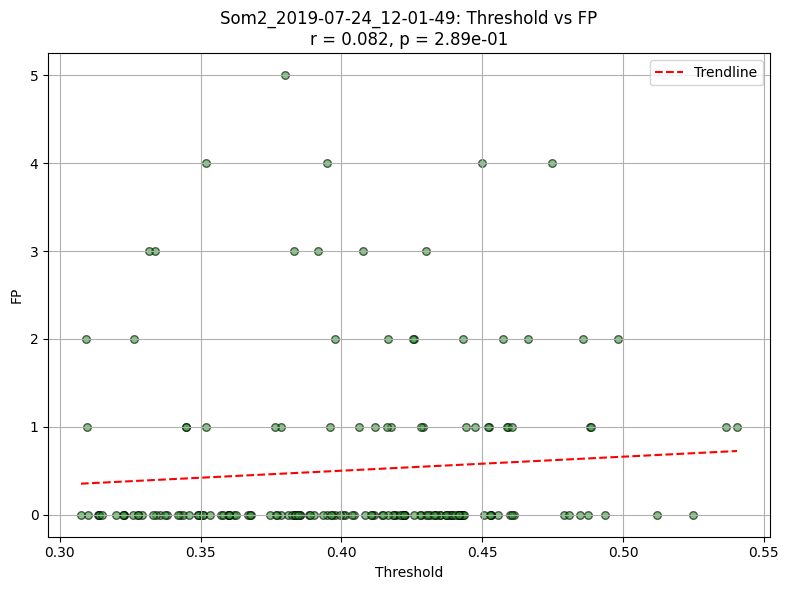

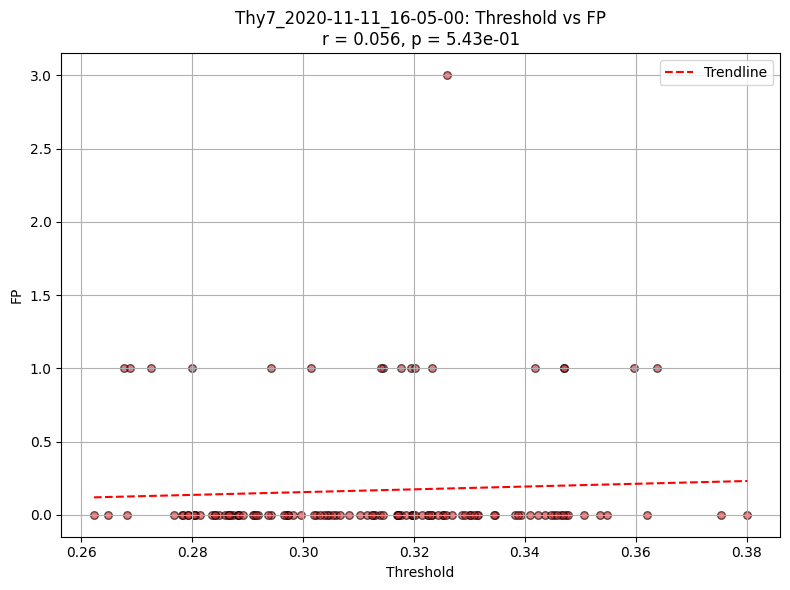

In [39]:
colors = plt.cm.tab10.colors  # color palette
# var = "FP"  # Change to "TP", "FN", etc. as needed

threshold_all = []
metric_all = []
dataset_labels = []

for i, dataset_name in enumerate(window_metrics_by_dataset.keys()):
    thresholds_dataset = []
    metric_dataset = []
    for ch in window_metrics_by_dataset[dataset_name].keys():
        thresholds = window_metrics_by_dataset[dataset_name][ch]["threshold"]
        metric_values = window_metrics_by_dataset[dataset_name][ch][var]
        
        if len(thresholds) != len(metric_values):
            print(f"Length mismatch in dataset {dataset_name}, channel {ch}")
            continue
        # Remove any pair where threshold is None
        filtered = [(t, m) for t, m in zip(thresholds, metric_values) if t is not None]

        if not filtered:
            continue  # Skip if nothing remains after filtering
        # Check how many were removed
        num_removed = len(thresholds) - len(filtered)
        if num_removed > 0:
            print(f"Removed {num_removed} entries with None thresholds in dataset {dataset_name}, channel {ch}")
            
        filtered_thresholds, filtered_metrics = zip(*filtered)

        thresholds_dataset.extend(filtered_thresholds)
        metric_dataset.extend(filtered_metrics)
    
    # Accumulate for overall
    threshold_all.extend(thresholds_dataset)
    metric_all.extend(metric_dataset)
    dataset_labels.extend([dataset_name] * len(metric_dataset))

    r_val, p_val = pearsonr(thresholds_dataset, metric_dataset)

    # Plot: threshold on x-axis, metric on y-axis
    plt.figure(figsize=(8, 6))
    plt.scatter(thresholds_dataset, metric_dataset, alpha=0.6, s=30,
                c=colors[i % len(colors)], edgecolors='k')

    # Trendline
    slope, intercept = np.polyfit(thresholds_dataset, metric_dataset, 1)
    x_vals = np.array([min(thresholds_dataset), max(thresholds_dataset)])
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color='red', linestyle='--', label='Trendline')

    plt.title(f"{dataset_name}: Threshold vs {var}\nr = {r_val:.3f}, p = {p_val:.2e}")
    plt.xlabel("Threshold")
    plt.ylabel(var)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Overall Pearson r = 0.068, p = 4.88e-02


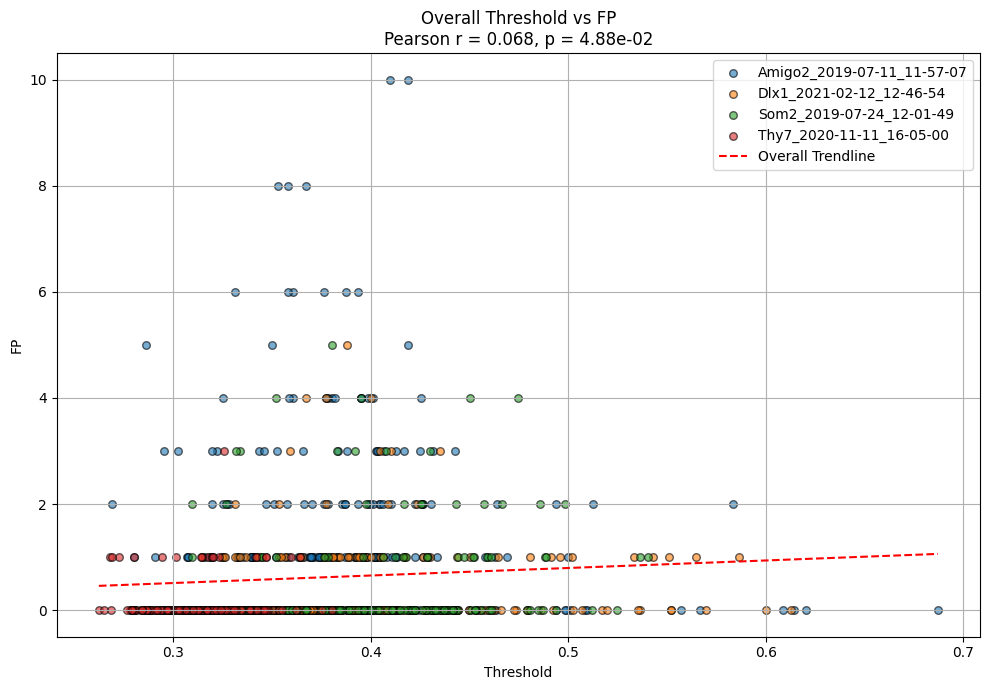

In [40]:
# Overall plot: Threshold vs Metric
plt.figure(figsize=(10, 7))
unique_datasets = list(window_metrics_by_dataset.keys())
for i, dataset_name in enumerate(unique_datasets):
    # Mask for current dataset
    mask = [label == dataset_name for label in dataset_labels]
    plt.scatter(
        [threshold_all[j] for j in range(len(threshold_all)) if mask[j]],
        [metric_all[j] for j in range(len(metric_all)) if mask[j]],
        alpha=0.6, s=30, c=[colors[i % len(colors)]], edgecolors='k', label=dataset_name
    )

# Overall correlation
r_all, p_all = pearsonr(threshold_all, metric_all)
print(f"Overall Pearson r = {r_all:.3f}, p = {p_all:.2e}")
plt.title(f"Overall Threshold vs {var}\nPearson r = {r_all:.3f}, p = {p_all:.2e}")

# Fit and plot overall trendline
slope, intercept = np.polyfit(threshold_all, metric_all, 1)
x_vals = np.array([min(threshold_all), max(threshold_all)])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', linestyle='--', label='Overall Trendline')

plt.xlabel("Threshold")
plt.ylabel(var)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


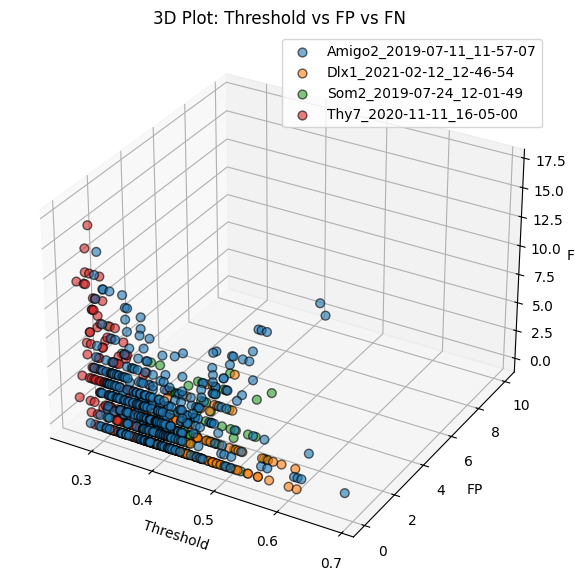

In [41]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

var = "FP"
third_var = "FN"

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Collect all data first
for i, dataset_name in enumerate(window_metrics_by_dataset.keys()):
    thresholds_dataset = []
    metric_dataset = []
    third_dataset = []

    for ch in window_metrics_by_dataset[dataset_name].keys():
        thresholds = window_metrics_by_dataset[dataset_name][ch]["threshold"]
        metric_values = window_metrics_by_dataset[dataset_name][ch][var]
        third_values = window_metrics_by_dataset[dataset_name][ch][third_var]

        if not (len(thresholds) == len(metric_values) == len(third_values)):
            continue

        thresholds_dataset.extend(thresholds)
        metric_dataset.extend(metric_values)
        third_dataset.extend(third_values)

    ax.scatter(
        thresholds_dataset,
        metric_dataset,
        third_dataset,
        color=colors[i % len(colors)],
        label=dataset_name,
        alpha=0.6,
        edgecolor='k',
        s=40
    )

ax.set_xlabel("Threshold")
ax.set_ylabel(var)
ax.set_zlabel(third_var)
ax.set_title(f"3D Plot: Threshold vs {var} vs {third_var}")
ax.legend()

# Animation function
def update(angle):
    ax.view_init(elev=20, azim=angle)
    return fig,

# Animate
ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)

# To display in Jupyter:
plt.show()

# To save as a video or GIF:
# ani.save("rotation.gif", writer='pillow', fps=20)
# ani.save("rotation.mp4", writer='ffmpeg', fps=20)
